In [81]:
from pathlib import Path
results_dir = Path("/mnt/ceph-hdd/cold/nim00020/hannibal_data/rf_models/classification_reports")
all_reports = list(results_dir.glob("*.json"))
CELL_NAME_ID = {
    "tumor_cells": 1,
    "stromal_cells": 2,
    "lymphocytes": 3,
    "others": 4,
    "neutrophils": 5,
    "epithelial_cells": 6,
}

SUBTYPE_NAME_ID = {
    "acinous": 1,
    "papillary": 2,
    "solid": 3,
    "mucinous": 4,
    "lepidic": 5,
    "lepidic_mixed": 6,
    "micropapillary": 7,
}

SUBTYPE_ID_NAME = {v: k for k, v in SUBTYPE_NAME_ID.items()}
CELL_ID_NAME = {v: k for k, v in CELL_NAME_ID.items()}
print(len(all_reports))

64


In [82]:
import json
import pandas as pd
from pathlib import Path

rows = []

for path in Path(results_dir).glob("*.json"):
    with open(path, "r") as f:
        report = json.load(f)
    rpl_path = path.stem.replace("lepidic_mixed", "lepidicmixed")
    subtype = "" if "overall" in path.stem else rpl_path.split("_")[-1]
    config = rpl_path.replace(subtype, "")
    config = config.replace("_overall", "")
    config = config.strip("_")
    for cls, metrics in report.items():
        if not isinstance(metrics, dict):
            continue  # skip accuracy etc.
        if len(cls) > 1:
            continue
        rows.append({
            "config": config,
            "subtype": subtype if subtype else "overall",
            "class": cls,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1-score"],
            "support": metrics["support"]
        })

df = pd.DataFrame(rows)

df["class"] = df["class"].astype(int)

df["class"] = df["class"].map(CELL_ID_NAME)
len(df['config'].unique())

8

/tmp/ipykernel_1640301/1306008935.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_df = df.groupby(['config', 'class'])[metric].mean().reset_index()


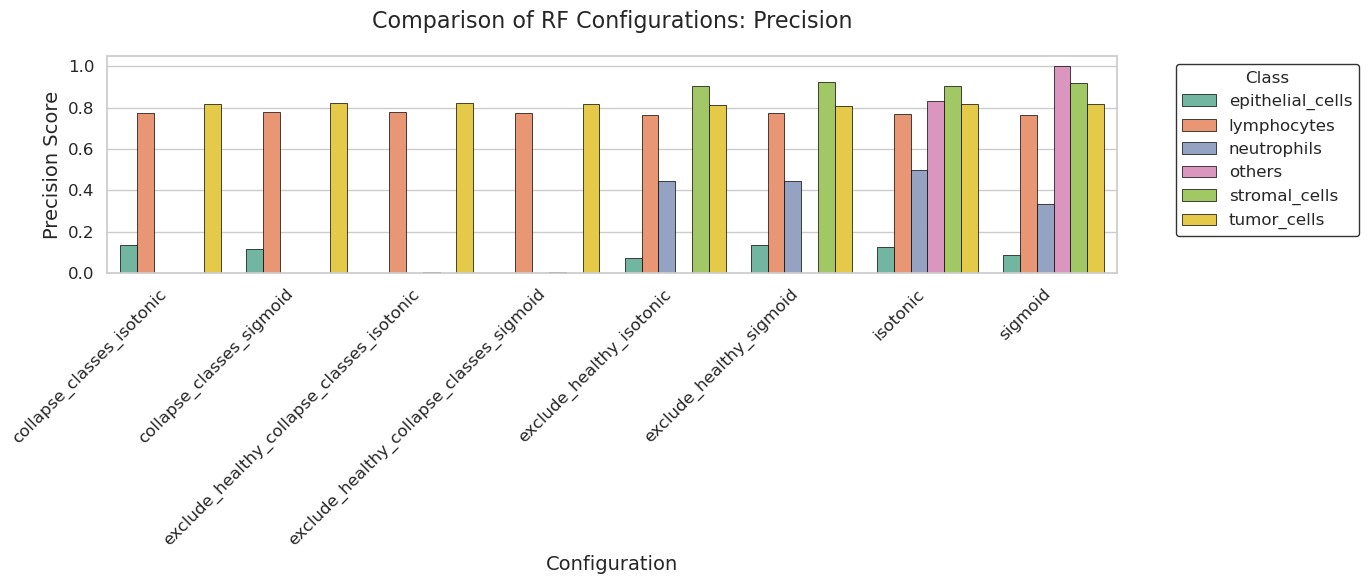

/tmp/ipykernel_1640301/1306008935.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_df = df.groupby(['config', 'class'])[metric].mean().reset_index()


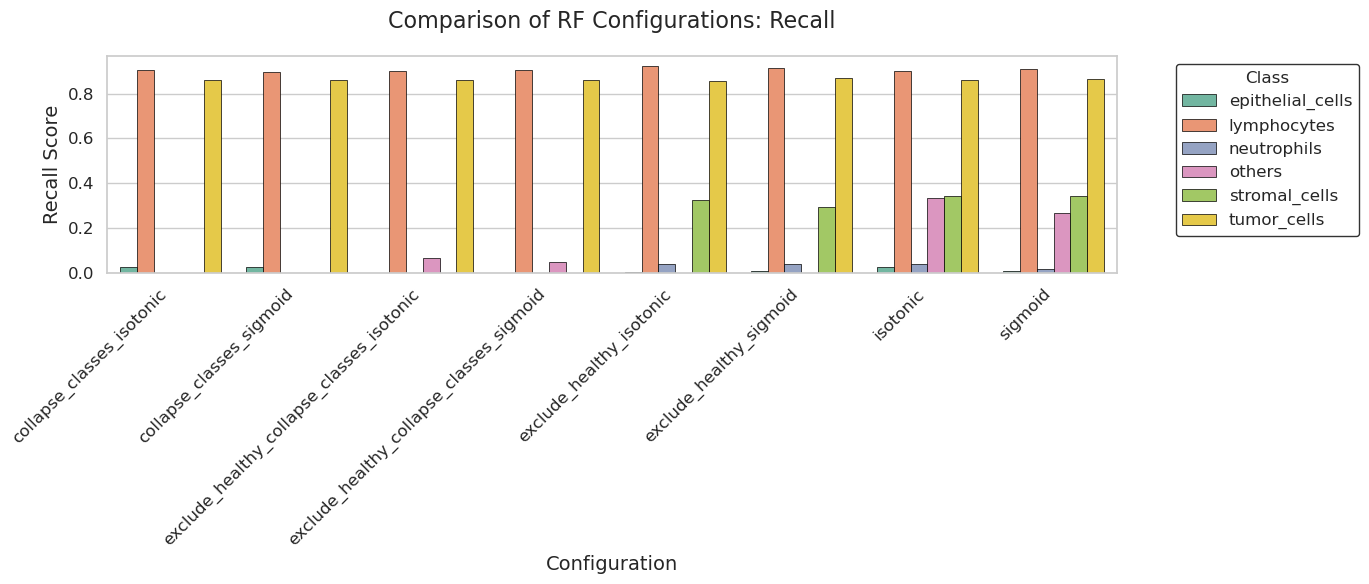

/tmp/ipykernel_1640301/1306008935.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_df = df.groupby(['config', 'class'])[metric].mean().reset_index()


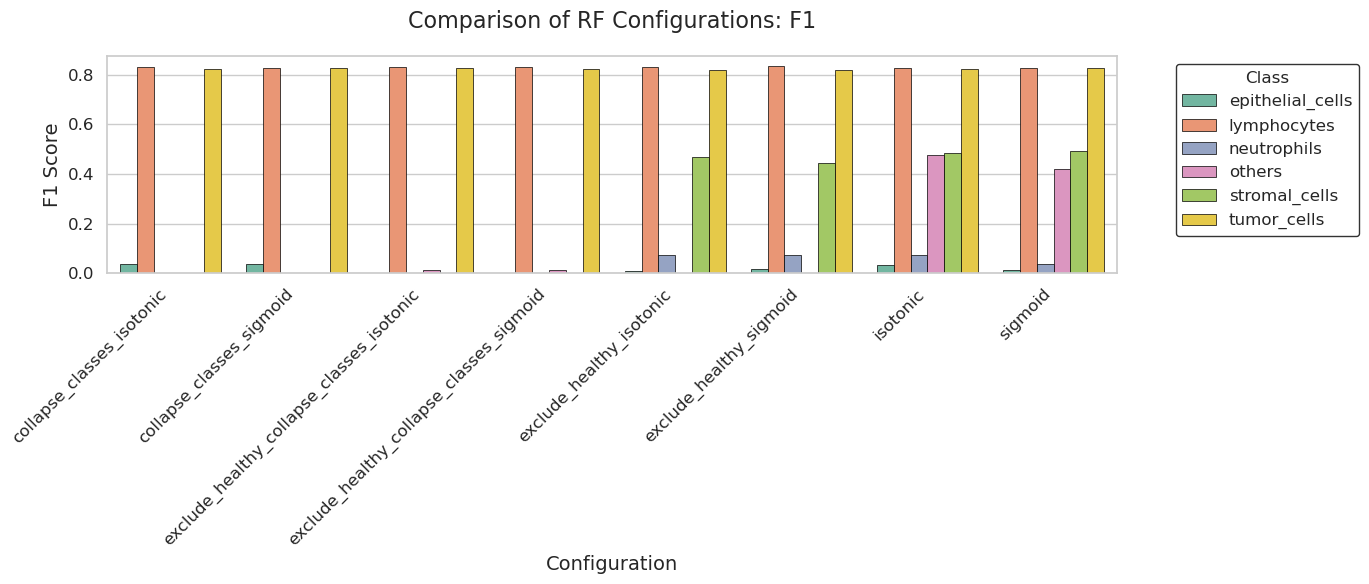

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set scientific style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

# Assuming your DataFrame is called `df`
# Ensure categorical order (optional but helpful)
df['config'] = pd.Categorical(df['config'], categories=sorted(df['config'].unique()))
df['class'] = pd.Categorical(df['class'], categories=sorted(df['class'].unique()))

# List of metrics to plot
metrics_to_plot = ['precision', 'recall', 'f1']

# Loop through each metric
for metric in metrics_to_plot:
    # Aggregate mean per config and class
    pivot_df = df.groupby(['config', 'class'])[metric].mean().reset_index()
    
    # Pivot to wide format
    pivot_wide = pivot_df.pivot(index='config', columns='class', values=metric).reset_index()
    
    # Melt back to long format for plotting
    pivot_long = pivot_wide.melt(
        id_vars='config',
        value_vars=pivot_wide.columns[1:],  # All class columns
        var_name='class',
        value_name=metric
    )
    
    # Create figure with more width
    fig, ax = plt.subplots(figsize=(14, 6))  # Increased width

    # Create grouped bar plot
    sns.barplot(
        data=pivot_long,
        x='config',
        y=metric,
        hue='class',
        palette='Set2',
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )
    
    # Customize labels and layout
    ax.set_title(f'Comparison of RF Configurations: {metric.capitalize()}', pad=20, fontsize=16)
    ax.set_xlabel('Configuration', fontsize=14)
    ax.set_ylabel(f'{metric.capitalize()} Score', fontsize=14)
    
    # Rotate x-axis labels and align them to the right
    plt.xticks(rotation=45, ha='right')
    
    # Move legend outside the plot
    legend = ax.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('black')
    
    # Adjust layout to prevent clipping
    plt.tight_layout()
    plt.subplots_adjust(right=0.8)  # Make room for legend
    
    # Show plot
    plt.show()

Filtering data to include only classes: ['lymphocytes', 'tumor_cells']
Rows after filtering to ['lymphocytes', 'tumor_cells']: 128
Rows for isotonic and classes ['lymphocytes', 'tumor_cells']: 16


/tmp/ipykernel_1640301/3837385803.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_df = df_config.groupby(['subtype', 'class'])[metric].mean().reset_index()


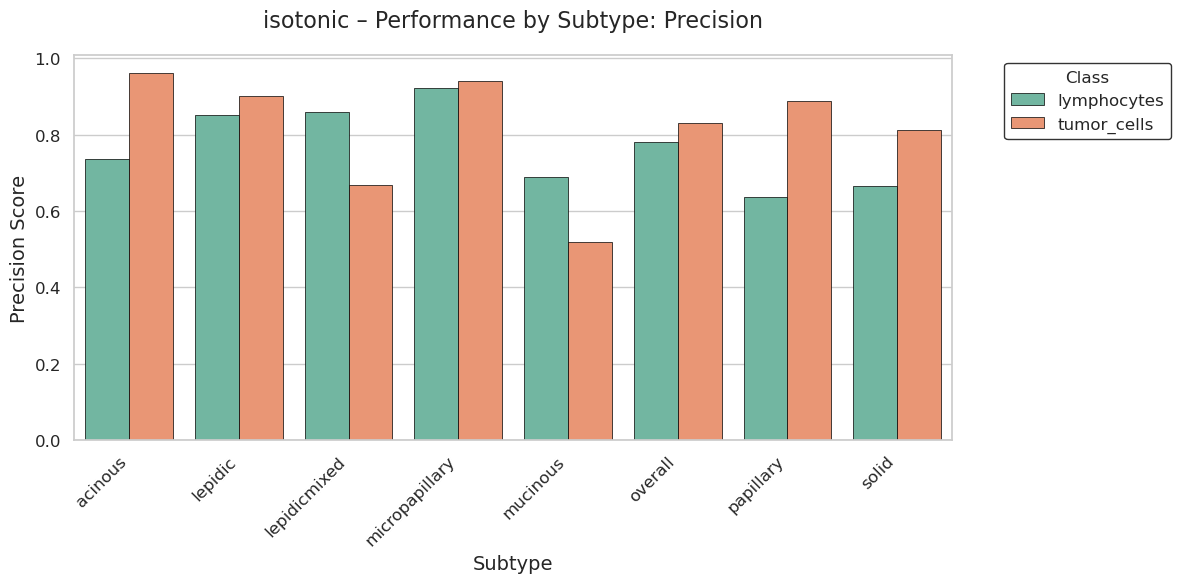

/tmp/ipykernel_1640301/3837385803.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_df = df_config.groupby(['subtype', 'class'])[metric].mean().reset_index()


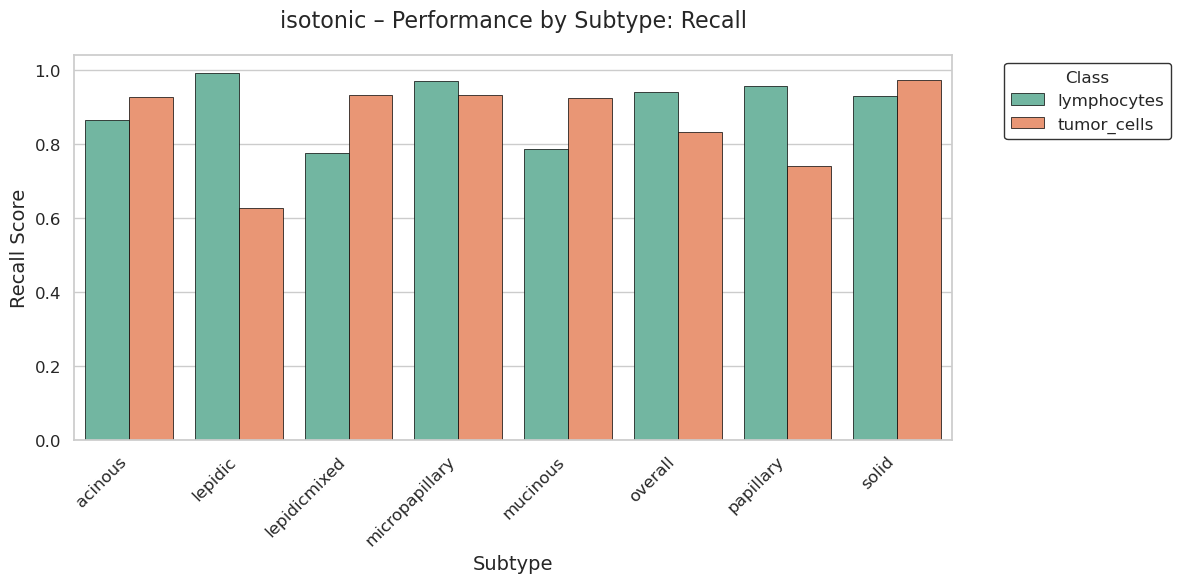

/tmp/ipykernel_1640301/3837385803.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_df = df_config.groupby(['subtype', 'class'])[metric].mean().reset_index()


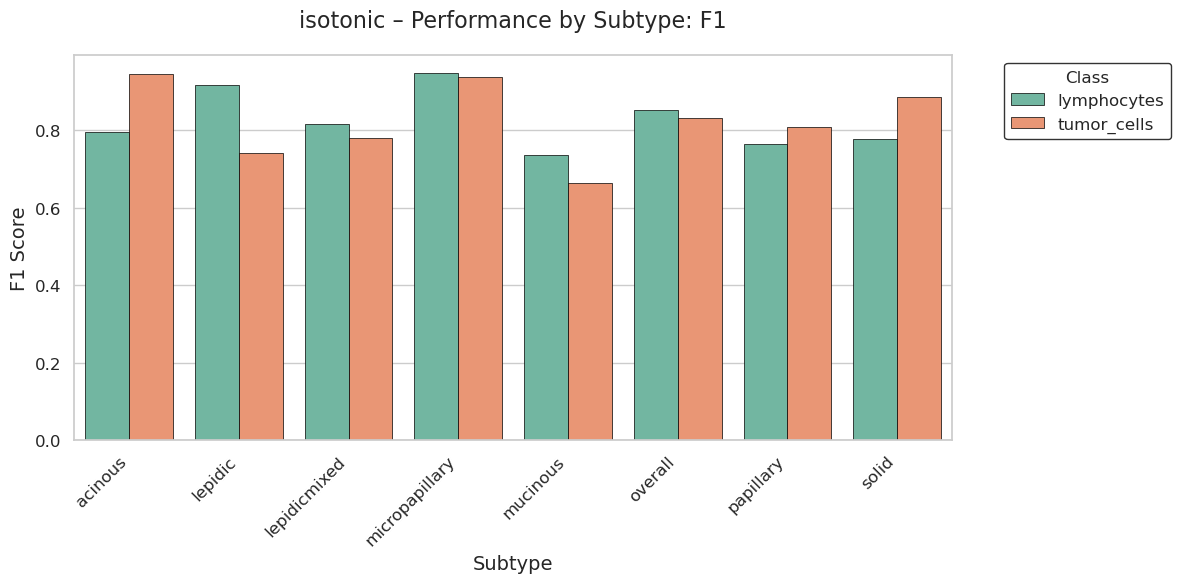

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

# 🔍 STEP 1: Define your list of classes to include
target_classes = ['lymphocytes', 'tumor_cells']  # ← CHANGE THIS TO YOUR DESIRED CLASSES

# Check if these classes exist
available_classes = set(df['class'].unique())
missing_classes = set(target_classes) - available_classes
if missing_classes:
    raise ValueError(f"Classes not found in data: {missing_classes}. Available: {available_classes}")

print(f"Filtering data to include only classes: {target_classes}")

# 🔍 STEP 2: Clean and filter data
df = df.dropna(subset=['subtype', 'class', 'precision', 'recall', 'f1'])
df['config'] = df['config'].astype(str)

# Filter to only desired classes
df_filtered = df[df['class'].isin(target_classes)].copy()

print(f"Rows after filtering to {target_classes}: {len(df_filtered)}")

# 🔍 STEP 3: Choose config to analyze
target_config = 'isotonic'  # ← Change to an actual config name from df['config'].unique()

if target_config not in df_filtered['config'].unique():
    raise ValueError(f"Config '{target_config}' not found in filtered data. Available: {df_filtered['config'].unique()}")

# Filter for this config
df_config = df_filtered[df_filtered['config'] == target_config].copy()

print(f"Rows for {target_config} and classes {target_classes}: {len(df_config)}")

# Ensure categorical order
df_config['subtype'] = pd.Categorical(df_config['subtype'], categories=sorted(df_config['subtype'].unique()))
df_config['class'] = pd.Categorical(df_config['class'], categories=target_classes)  # Use only your list

# Metrics to plot
metrics_to_plot = ['precision', 'recall', 'f1']

# Loop through each metric
for metric in metrics_to_plot:
    # Check if data exists
    if df_config[metric].isna().all():
        print(f"⚠️ No valid {metric} data for {target_config} and classes {target_classes}")
        continue

    # Aggregate
    pivot_df = df_config.groupby(['subtype', 'class'])[metric].mean().reset_index()
    
    # Pivot
    pivot_wide = pivot_df.pivot(index='subtype', columns='class', values=metric).reset_index()
    
    # Melt
    pivot_long = pivot_wide.melt(
        id_vars='subtype',
        value_vars=pivot_wide.columns[1:],
        var_name='class',
        value_name=metric
    )
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=pivot_long,
        x='subtype',
        y=metric,
        hue='class',
        palette='Set2',
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )
    
    ax.set_title(f'{target_config} – Performance by Subtype: {metric.capitalize()}', pad=20, fontsize=16)
    ax.set_xlabel('Subtype', fontsize=14)
    ax.set_ylabel(f'{metric.capitalize()} Score', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    
    legend = ax.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('black')
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.8)
    plt.show()

✅ Filtering data to include only classes: ['lymphocytes', 'tumor_cells']
✅ Rows after filtering to ['lymphocytes', 'tumor_cells']: 128


/tmp/ipykernel_1640301/2204028089.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_df = df_filtered.groupby(['config', 'class'])[metric].mean().reset_index()


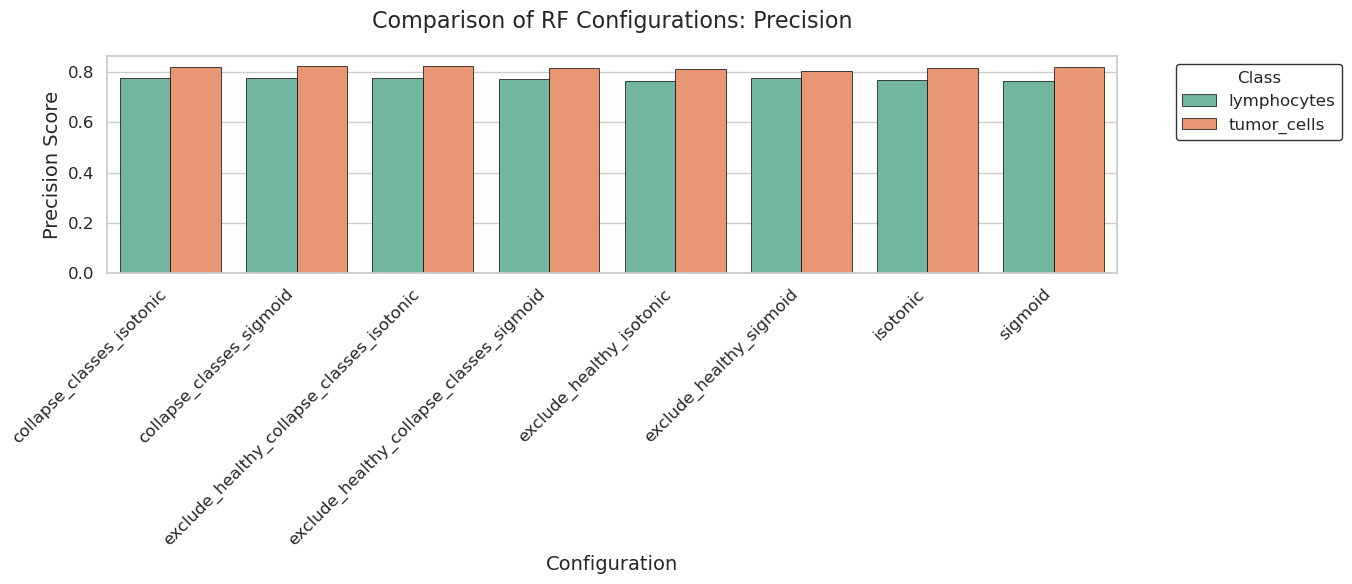

/tmp/ipykernel_1640301/2204028089.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_df = df_filtered.groupby(['config', 'class'])[metric].mean().reset_index()


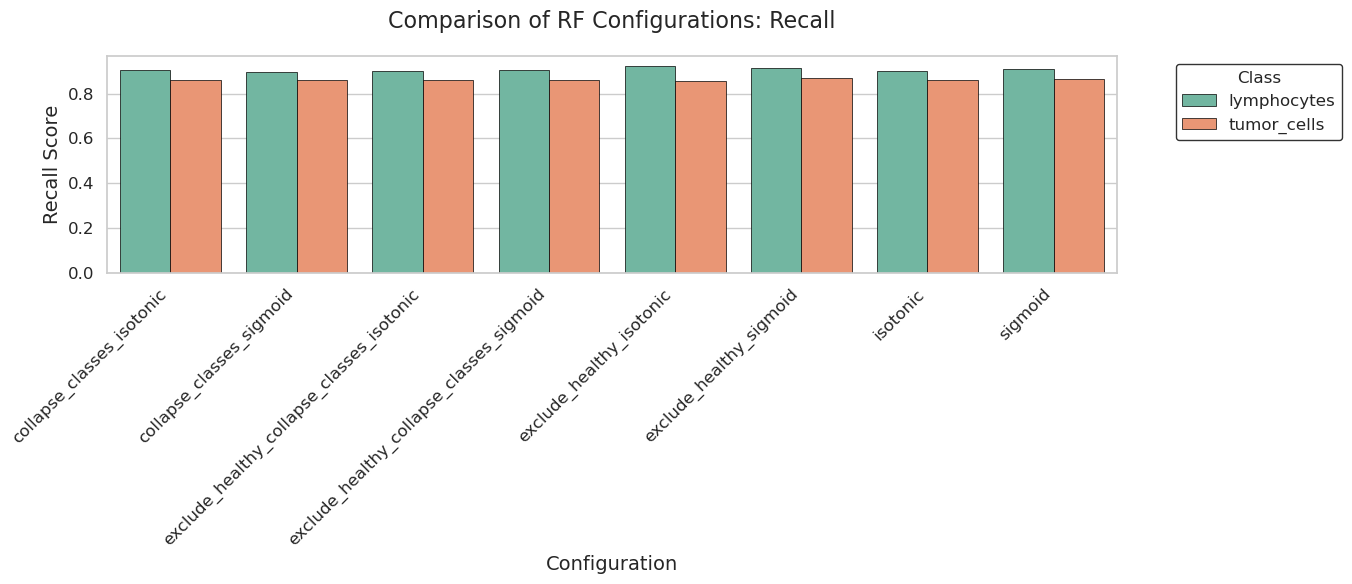

/tmp/ipykernel_1640301/2204028089.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_df = df_filtered.groupby(['config', 'class'])[metric].mean().reset_index()


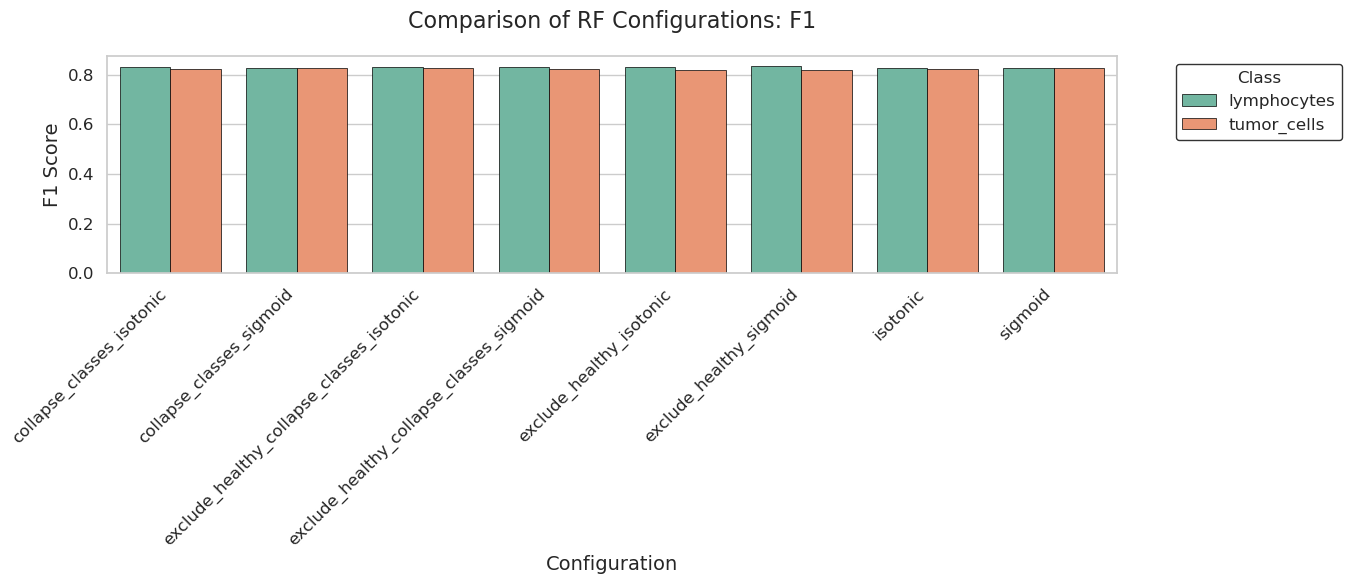

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set scientific style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

# 🔧 USER INPUT: Define which classes to include in the plots
target_classes = ['lymphocytes', 'tumor_cells']  # ← CHANGE THIS TO YOUR DESIRED CLASSES

# 🔍 Validate target_classes
available_classes = set(df['class'].unique())
missing_classes = set(target_classes) - available_classes
if missing_classes:
    raise ValueError(f"Classes not found in data: {missing_classes}. Available: {available_classes}")

print(f"✅ Filtering data to include only classes: {target_classes}")

# 🔍 Step 1: Clean data (remove missing values)
df_clean = df.dropna(subset=['config', 'class', 'precision', 'recall', 'f1'])

# Ensure categorical order
df_clean['config'] = pd.Categorical(df_clean['config'], categories=sorted(df_clean['config'].unique()))
df_clean['class'] = pd.Categorical(df_clean['class'], categories=target_classes)  # Only include target classes

# Filter to only desired classes
df_filtered = df_clean[df_clean['class'].isin(target_classes)].copy()

print(f"✅ Rows after filtering to {target_classes}: {len(df_filtered)}")

# List of metrics to plot
metrics_to_plot = ['precision', 'recall', 'f1']

# Loop through each metric
for metric in metrics_to_plot:
    # Aggregate mean per config and class
    pivot_df = df_filtered.groupby(['config', 'class'])[metric].mean().reset_index()
    
    # Pivot to wide format
    pivot_wide = pivot_df.pivot(index='config', columns='class', values=metric).reset_index()
    
    # Melt back to long format for plotting
    pivot_long = pivot_wide.melt(
        id_vars='config',
        value_vars=pivot_wide.columns[1:],  # Only target classes
        var_name='class',
        value_name=metric
    )
    
    # Create figure with more width
    fig, ax = plt.subplots(figsize=(14, 6))

    # Create grouped bar plot
    sns.barplot(
        data=pivot_long,
        x='config',
        y=metric,
        hue='class',
        palette='Set2',
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )
    
    # Customize labels and layout
    ax.set_title(f'Comparison of RF Configurations: {metric.capitalize()}', pad=20, fontsize=16)
    ax.set_xlabel('Configuration', fontsize=14)
    ax.set_ylabel(f'{metric.capitalize()} Score', fontsize=14)
    
    # Rotate x-axis labels and align them to the right
    plt.xticks(rotation=45, ha='right')
    
    # Move legend outside the plot
    legend = ax.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('black')
    
    # Adjust layout to prevent clipping
    plt.tight_layout()
    plt.subplots_adjust(right=0.8)  # Make room for legend
    
    # Show plot
    plt.show()